# Testing Suit

In [2]:
import analysing_utils
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
variants = [
    'selection-UCB'
#     # Standard
#     'standard',
#     'standard_nc',
#     'standard_nc_prob',
#     'terminal_nc',
#     'terminal',
#     # Actions
#     'actions',
#     'actions_gates',
#     'actions_gates_terminal',
#     'actions_terminal',
#     'actions_change_gates_swap',
#     'actions_change_gates_swap_terminal',
#     # Gates
#     'gates',
#     'gates_terminal',

# # Progresenive widening

#     # Actions
#     'actions_pw',
#     'actions_gates_pw',
#     'actions_gates_pw_terminal',
#     'actions_pw_terminal',
#     'actions_change_gates_pw_swap',
#     'actions_change_gates_pw_swap_terminal',
#     # Gates
#     'gates_pw',
#     'gates_pw_terminal',

    
]# 'action_change_gates_swap_terminal', 'terminal', 'gates_terminal', 'action_gates_terminal', 'action_terminal']
problems = ['h2', 'h2o', 'lih', 'vqls_0', 'vqls_1']
vql_problems = ['vqls_0', 'vqls_1']
chemistry_problems = ['h2', 'h2o', 'lih']
optimal_value = {'h2': 1.117, 'h2o': 75.42175236224648, 'lih': 7.95265005, 'vqls_0': 1, 'vqls_1': 1}

In [4]:
split_variants = []
for variant in variants:
    split_variants = split_variants + variant.split('_')
unique_vars = list(set(split_variants))
unique_vars

table_df = pd.DataFrame(columns=unique_vars)
table_df.head()

for variant in variants:
    variant.split('_')
    for col in unique_vars:
        table_df.at[variant, col] = 1 if col in variant.split('_') else 0

In [5]:
results = analysing_utils.load_mcts_results()

In [34]:
circuit_results = analysing_utils.load_circuit_results()

In [7]:
problem_stats = {}
for problem in problems:
    problem_results = []
    for variant in variants:
        problem_results.append(circuit_results[problem][variant])
    problem_stats[problem] =  analysing_utils.standardize_problem_stats(problem_results)

problem_stats
analysing_utils.standardize_from_stats(problem_stats["h2"], circuit_results["h2"]["gates"][0])

0.26372244172589904

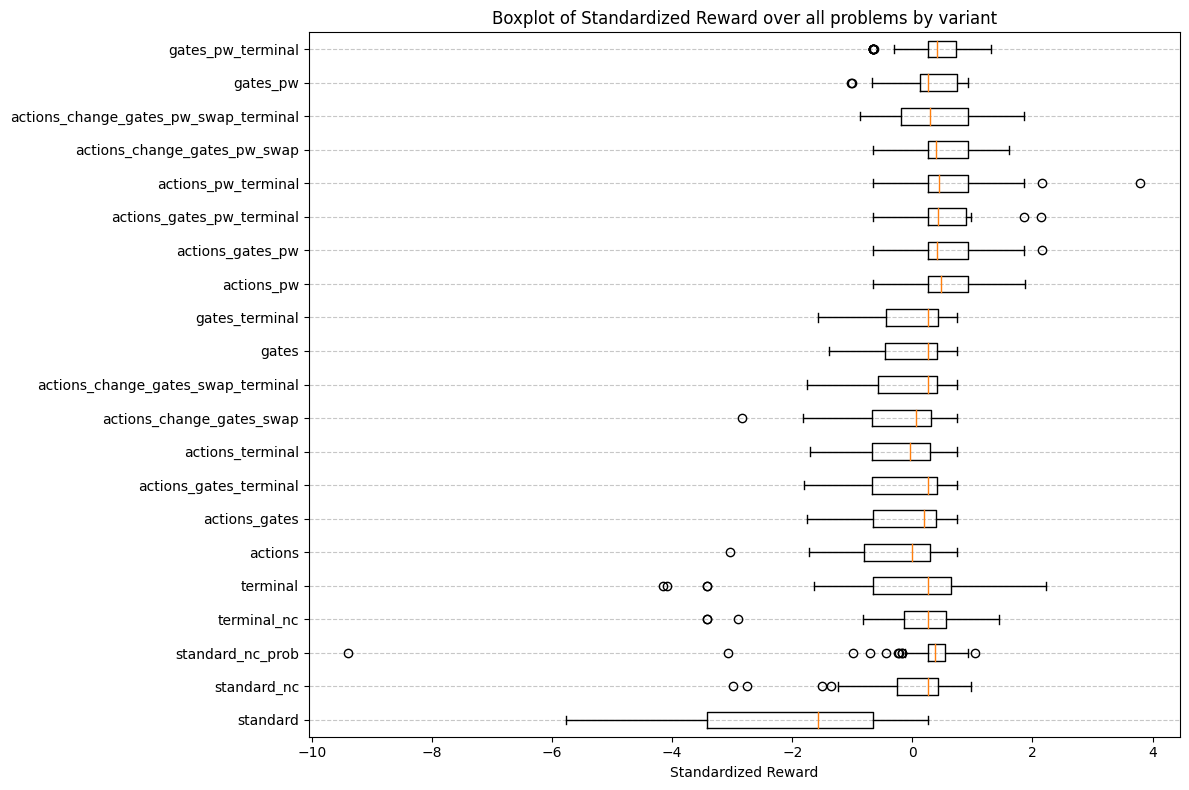

In [8]:
variant_results = {}
for variant in variants:
    standardized_results = []
    for problem in problems:
        for run in circuit_results[problem][variant]:
            result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
            standardized_results.append(result)
    variant_results[variant] = standardized_results

variant_results
plt.figure(figsize=(12, 8))
plt.boxplot(variant_results.values(), labels=variant_results.keys(), vert=False)
plt.xlabel('Standardized Reward')
plt.title('Boxplot of Standardized Reward over all problems by variant')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
plt.show()

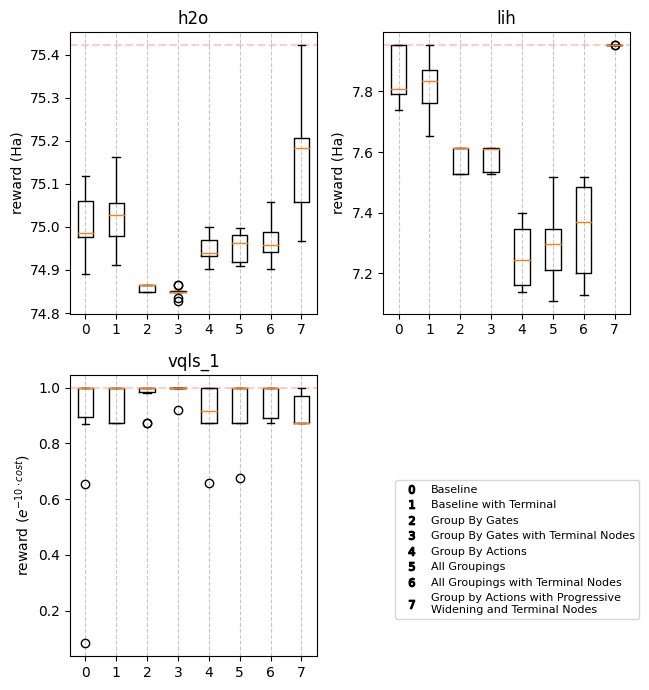

In [23]:
curate = ['standard_nc_prob','terminal_nc', 'gates', 'gates_terminal', 'actions', 'actions_change_gates_swap', 'actions_change_gates_swap_terminal','actions_pw_terminal']
circuit_results_curated = {problem: {key: circuit_results[problem][key] for key in curate if key in circuit_results[problem]} for problem in problems}

problems_curated = problems.copy()
problems_curated.remove('vqls_0')
problems_curated.remove('h2')
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(6.5, 7))
axes = axes.flatten()

for i, problem in enumerate(problems_curated):
    ax = axes[i]
    ax.boxplot(circuit_results_curated[problem].values(), labels=range(len(circuit_results_curated[problem].keys())))
    ax.axhline(y=optimal_value[problem], color='red', linestyle='--', alpha=0.2)
    ax.set_title(f"{problem}")
    if problem in ['h2o', 'lih']:
        ax.set_ylabel("reward (Ha)")
    else:
        ax.set_ylabel(r"reward ($e^{-10 \cdot cost}$)")
    ax.grid(axis='x', linestyle='--', alpha=0.7)  # Add horizontal grid lines

labels = ['Baseline', 'Baseline with Terminal', 'Group By Gates','Group By Gates with Terminal Nodes', 'Group By Actions', 'All Groupings', 'All Groupings with Terminal Nodes', 'Group by Actions with Progressive \nWidening and Terminal Nodes']
import matplotlib.lines as mlines

# Create dummy handles for the legend
handles = [mlines.Line2D([], [], color='black', marker=f'${i}$', linestyle='None') for i in range(8)]
fig.legend(handles, labels, loc='lower right', ncol=1, bbox_to_anchor=(1, 0.1), prop={'size': 8})  
axes[-1].axis('off')  # Hide the last subplot
plt.tight_layout()
plt.show()


['Group by Actions', 'All Groupings with Progressive Widening', 'All Groupings and Terminal Nodes with Progressive Widening', 'All Groupings', 'All Groupings and Terminal Nodes', 'Group by Actions and Gates', 'Group by Actions and Gates with Progressive Widening', 'Group by Actions, Gates and Terminal Nodes with Progressive Widening', 'Group by Actions, Gates and Terminal Nodes', 'Group by Actions with Progressive Widening', 'Group by Actions and Terminal Nodes \n with Progressive Widening', 'Group by Actions and Terminal Nodes', 'Group by Gates', 'Group by Gates with Progressive Widening', 'Group by Gates and Terminal Nodes with Progressive Widening', 'Group by Gates and Terminal Nodes', 'Standard', 'Standard without commiting', 'Baseline', 'Terminal Nodes', 'Terminal Nodes without commiting']


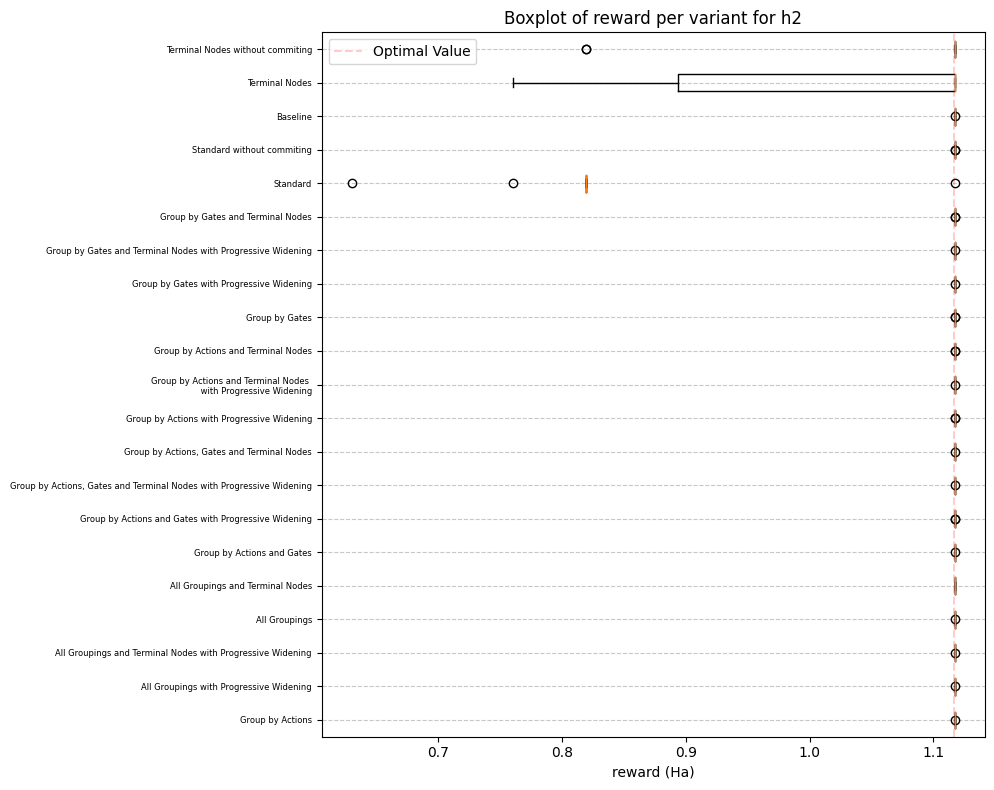

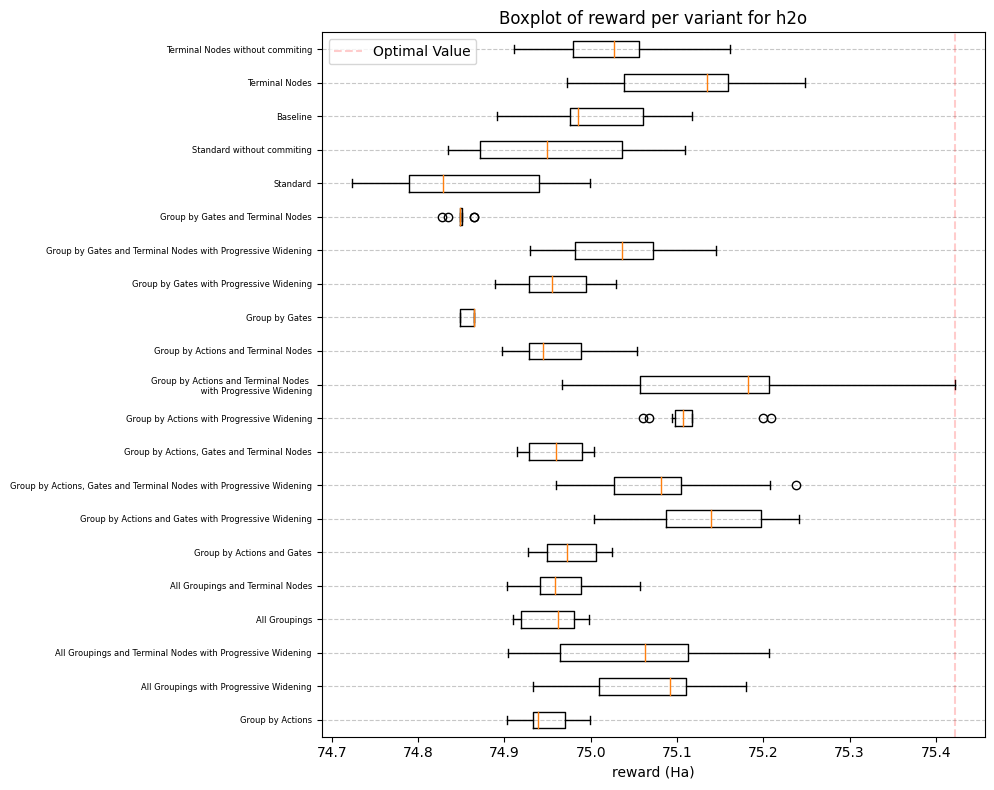

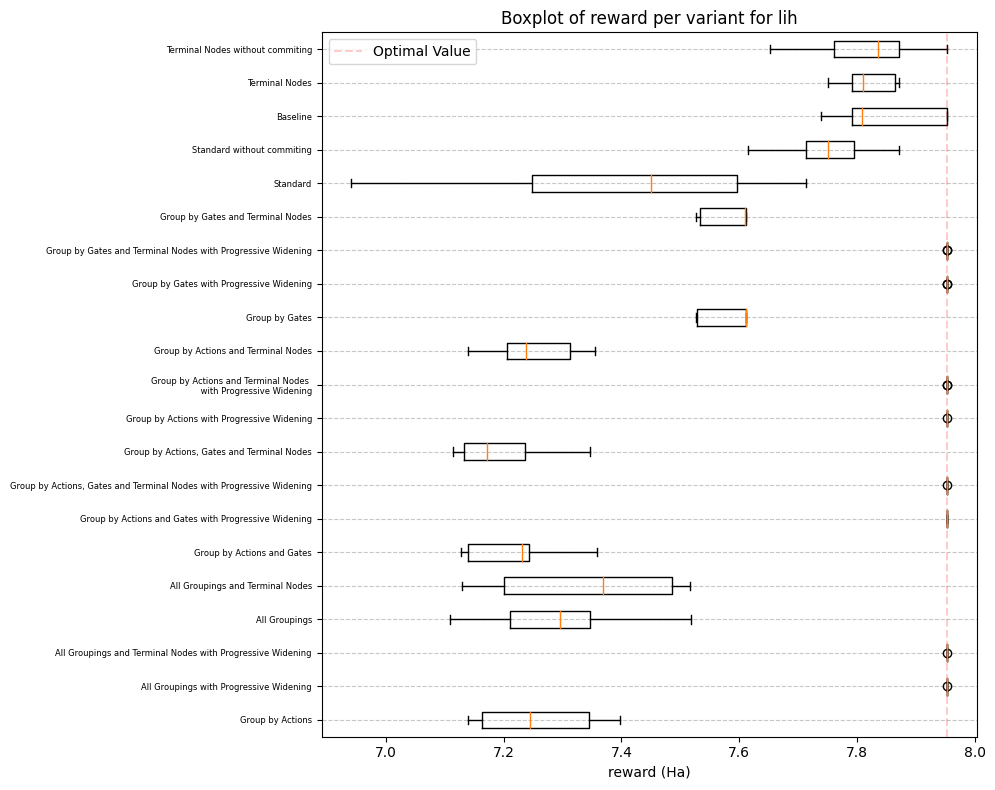

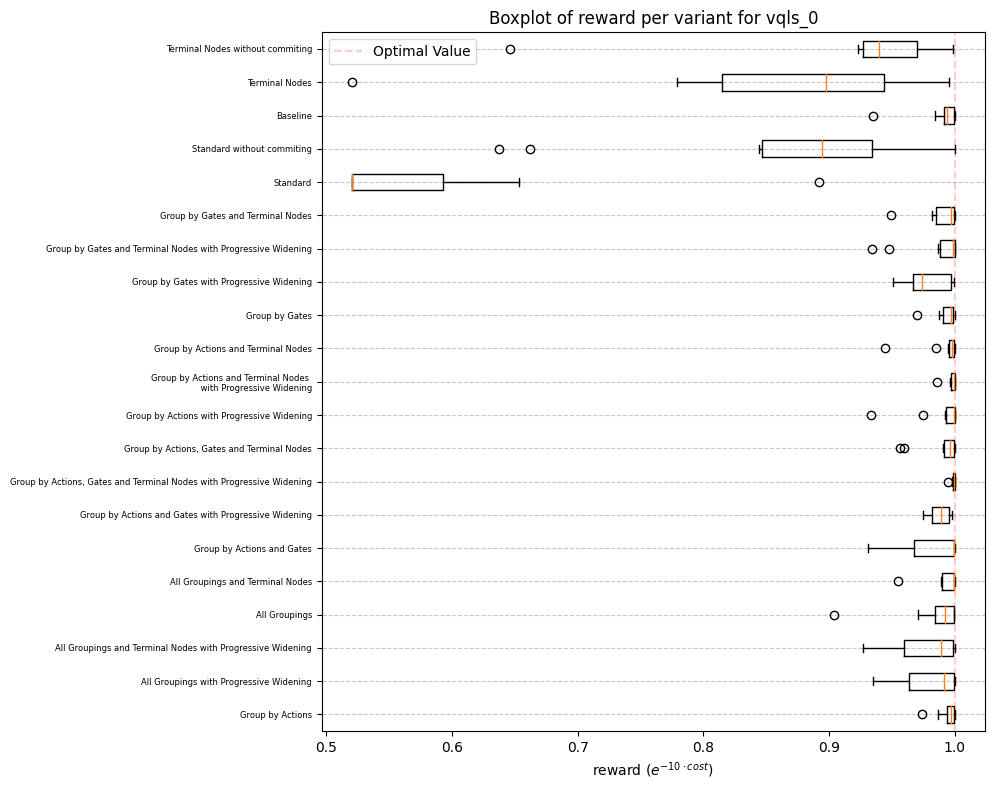

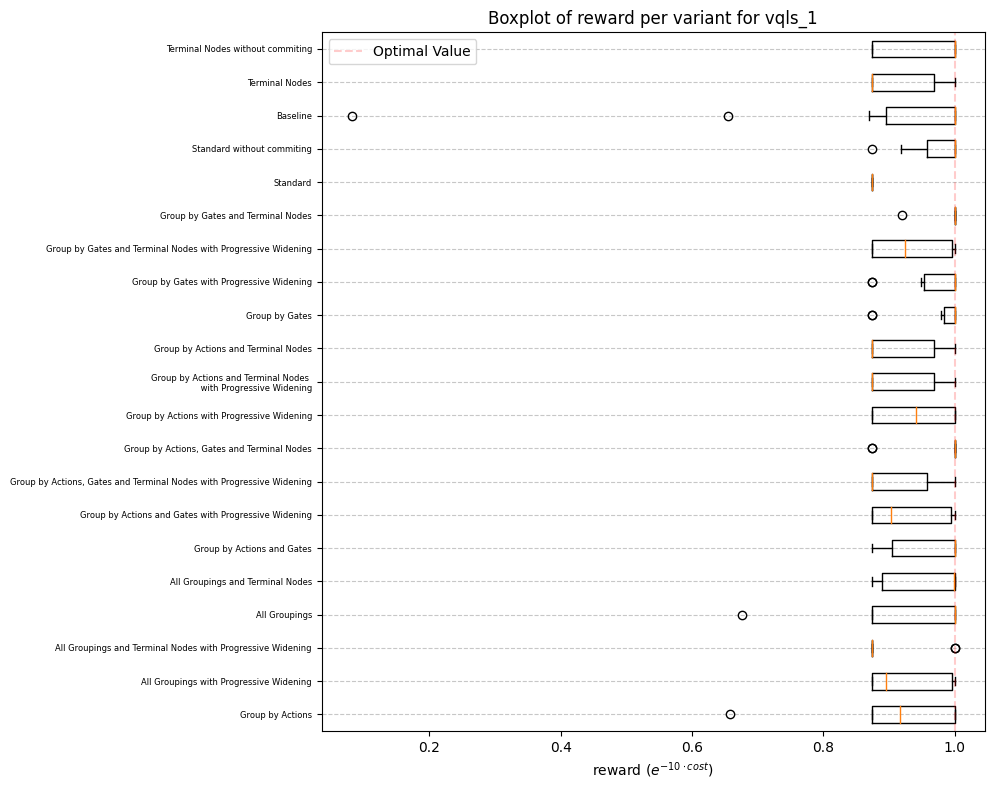

In [38]:
rename =  {
    "standard": "Standard",
    "standard_nc": "Standard without commiting",
    "standard_nc_prob": "Baseline",  # TODO: Make correct baseline blue
    "terminal_nc": "Terminal Nodes without commiting",
    "terminal": "Terminal Nodes",

    "actions": "Group by Actions",
    "actions_pw": "Group by Actions with Progressive Widening",

    "gates": "Group by Gates",
    "gates_pw": "Group by Gates with Progressive Widening",

    "actions_gates": "Group by Actions and Gates",
    "actions_gates_pw": "Group by Actions and Gates with Progressive Widening",

    "actions_terminal": "Group by Actions and Terminal Nodes",
    "actions_pw_terminal": "Group by Actions and Terminal Nodes \n with Progressive Widening",

    "gates_terminal": "Group by Gates and Terminal Nodes",
    "gates_pw_terminal": "Group by Gates and Terminal Nodes with Progressive Widening",

    "actions_gates_terminal": "Group by Actions, Gates and Terminal Nodes",
    "actions_gates_pw_terminal": "Group by Actions, Gates and Terminal Nodes with Progressive Widening",

    "actions_change_gates_swap": "All Groupings",
    "actions_change_gates_pw_swap": "All Groupings with Progressive Widening",

    "actions_change_gates_swap_terminal": "All Groupings and Terminal Nodes",
    "actions_change_gates_pw_swap_terminal": "All Groupings and Terminal Nodes with Progressive Widening",
}
labels=[rename.get(label, label) for label in circuit_results[problem].keys()]
print(labels)
for problem in problems:
    
    plt.figure(figsize=(12, 8))
    plt.boxplot(circuit_results[problem].values(), labels = labels, vert=False)
    plt.axvline(x=optimal_value[problem], color='red', linestyle='--', label='Optimal Value', alpha=0.2)
    if problem in ['h2', 'h2o', 'lih']:
        plt.xlabel("reward (Ha)")
    else:
        plt.xlabel(r"reward ($e^{-10 \cdot cost}$)")
    plt.title(f"Boxplot of reward per variant for {problem}")
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
    plt.legend()
    plt.yticks(fontsize=6)
    plt.show()

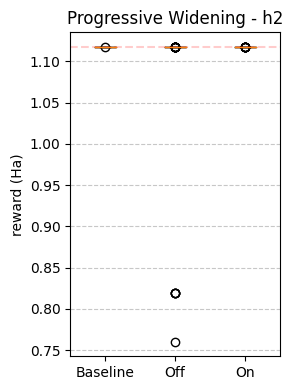

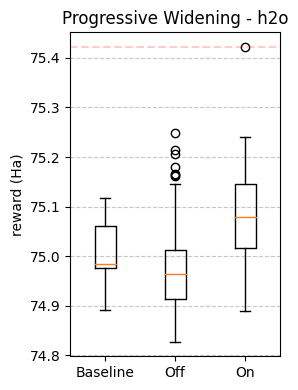

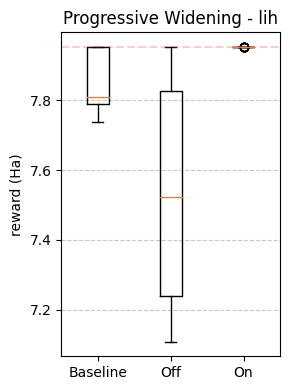

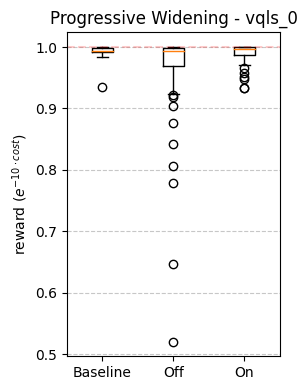

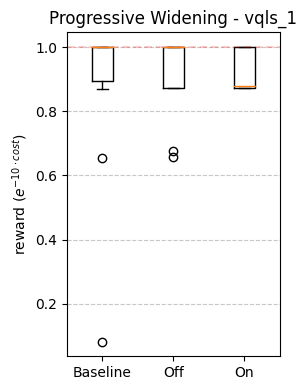

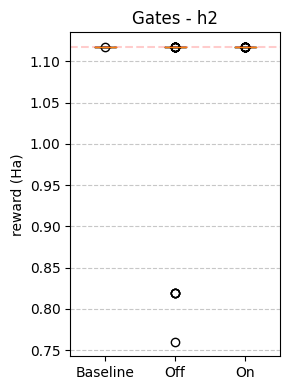

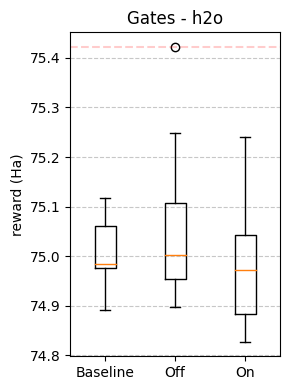

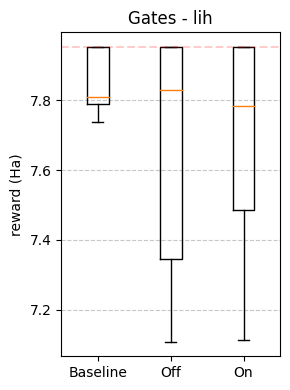

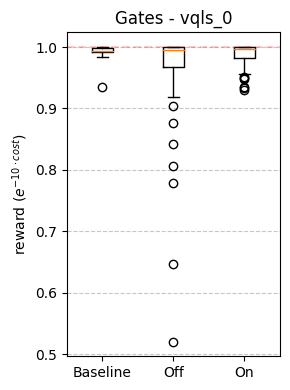

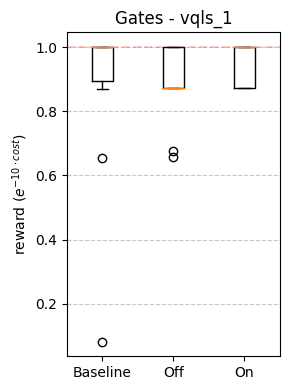

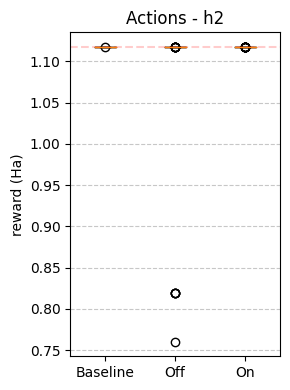

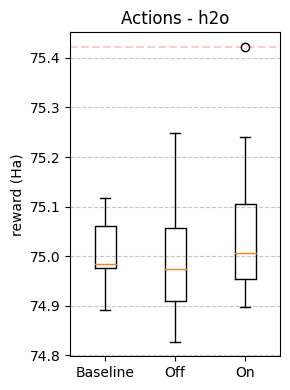

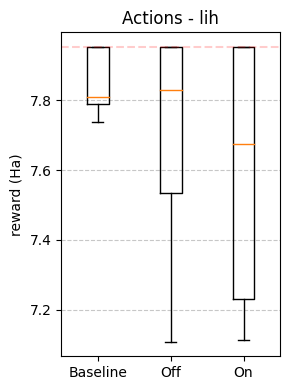

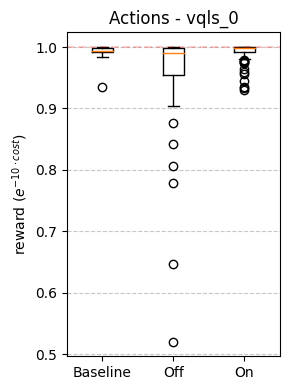

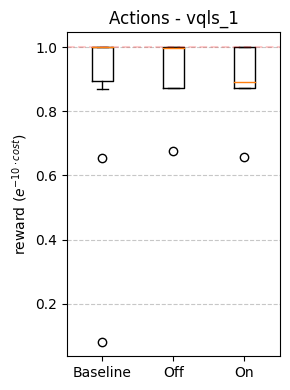

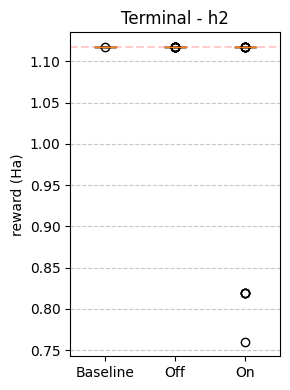

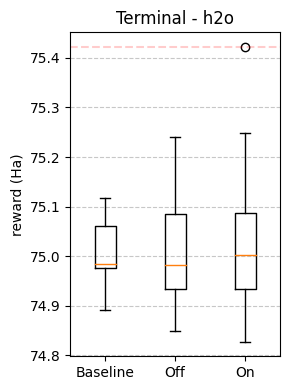

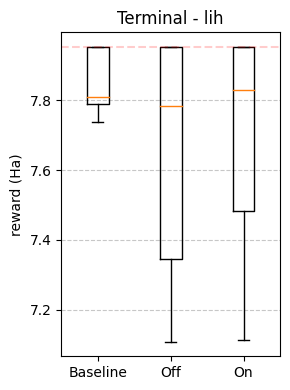

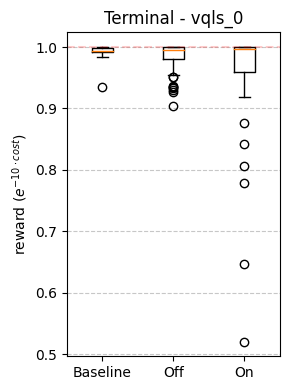

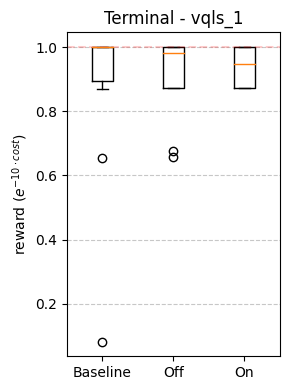

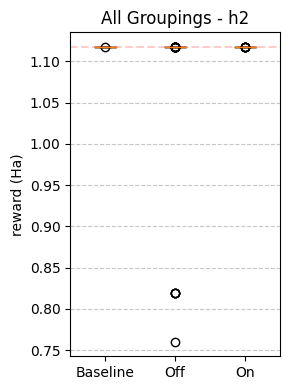

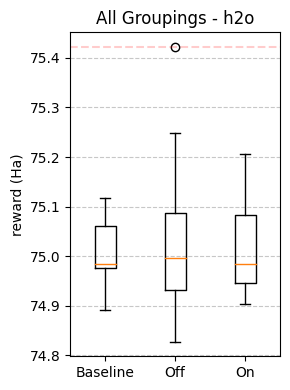

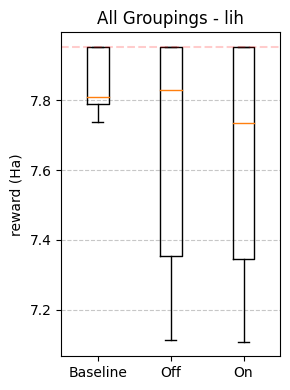

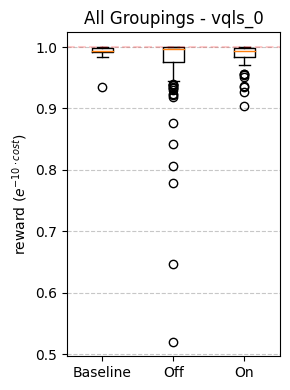

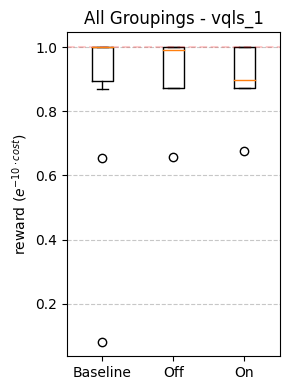

In [46]:
to_sort = ["pw", "gates", "actions", "terminal", "change"]
names = ["Progressive Widening", "Gates", "Actions", "Terminal", "All Groupings"]

for name, sort_by in zip(names, to_sort):
    for problem in problems:
        in_group = []
        standard = []
        out_group = []
        for variant in circuit_results[problem].keys():
            if sort_by != "change" and "change" in variant:
                out_group = out_group + circuit_results[problem][variant]
            elif sort_by in variant:
                in_group = in_group + circuit_results[problem][variant]
            elif "standard_nc_prob" == variant:
                standard = standard + circuit_results[problem][variant]
            elif "standard" not in variant:
                out_group = out_group + circuit_results[problem][variant]
        
        plt.figure(figsize=(3, 4))
        plt.boxplot([standard, out_group, in_group], labels=['Baseline', 'Off', 'On'])
        plt.title(f"{name} - {problem}")
        plt.axhline(y=optimal_value[problem], color='red', linestyle='--', label='Optimal Value', alpha=0.2)
        plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
        if problem in ['h2', 'h2o', 'lih']:
            plt.ylabel("reward (Ha)")
        else:
            plt.ylabel(r"reward ($e^{-10 \cdot cost}$)")
        plt.tight_layout()
        plt.savefig(f"groupboxplots/{sort_by}_{problem}.png")
        plt.show()


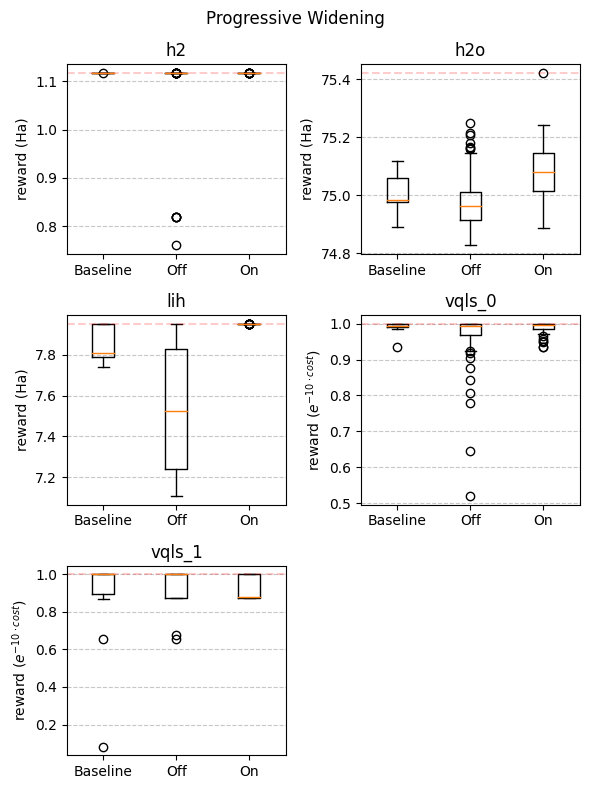

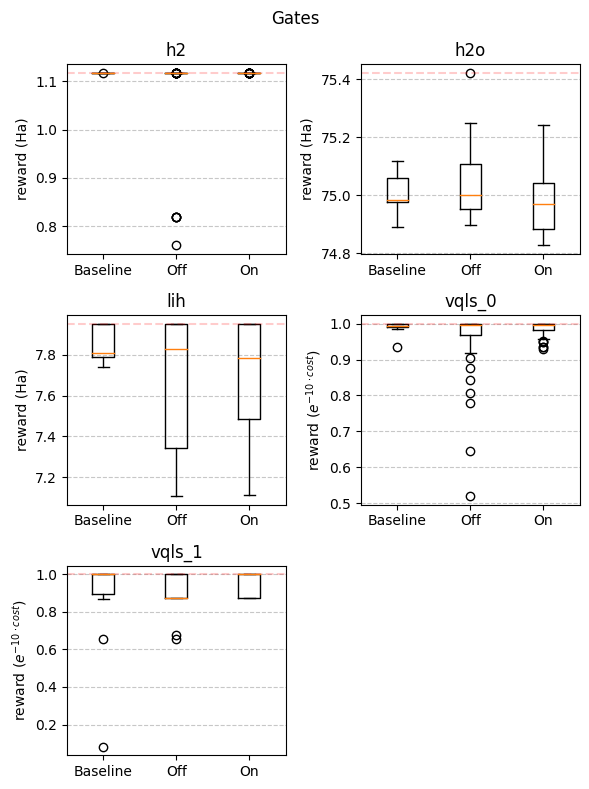

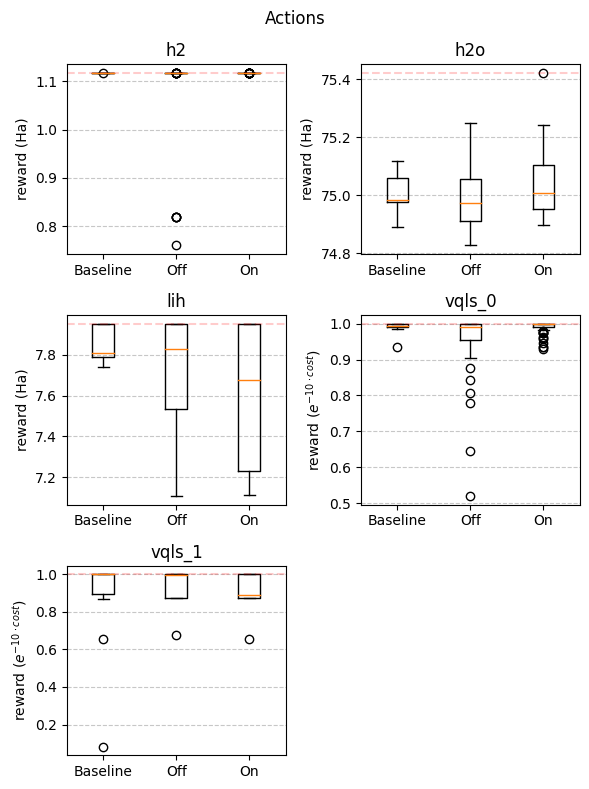

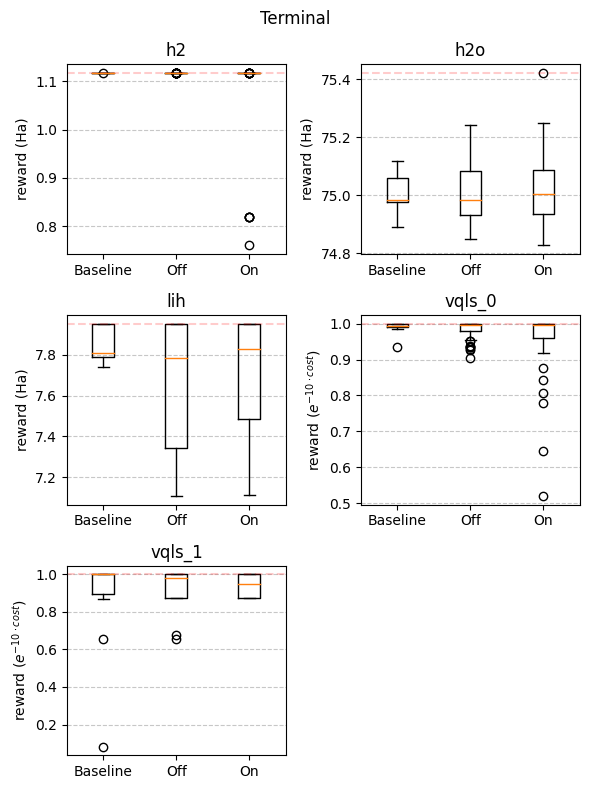

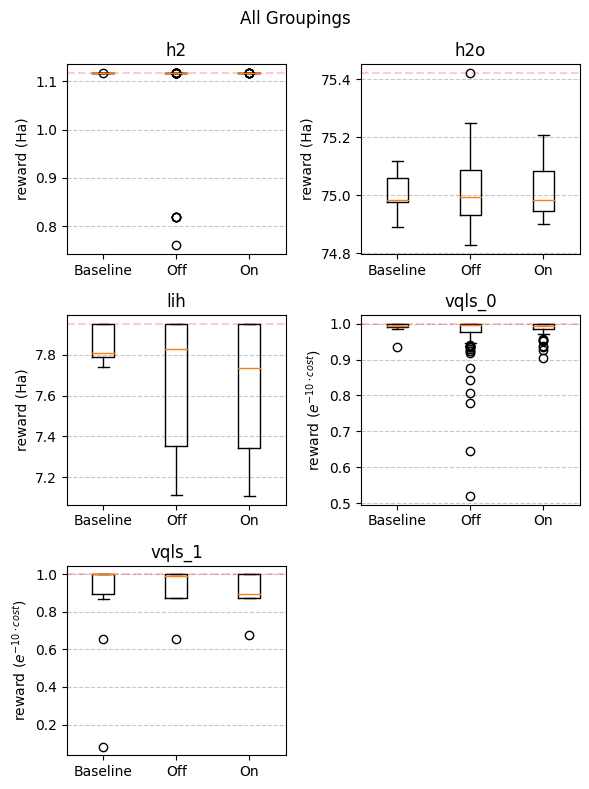

In [47]:
to_sort = ["pw", "gates", "actions", "terminal", "change"]
names = ["Progressive Widening", "Gates", "Actions", "Terminal", "All Groupings"]

for name, sort_by in zip(names, to_sort):
    fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(6, 8))
    axes = axes.flatten()
    
    for i, problem in enumerate(problems):
        in_group = []
        standard = []
        out_group = []
        for variant in circuit_results[problem].keys():
            if sort_by != "change" and "change" in variant:
                out_group = out_group + circuit_results[problem][variant]
            elif sort_by in variant:
                in_group = in_group + circuit_results[problem][variant]
            elif "standard_nc_prob" == variant:
                standard = standard + circuit_results[problem][variant]
            elif "standard" not in variant:
                out_group = out_group + circuit_results[problem][variant]
        
        ax = axes[i]
        ax.boxplot([standard, out_group, in_group], labels=['Baseline', 'Off', 'On'])
        ax.set_title(f"{problem}")
        ax.axhline(y=optimal_value[problem], color='red', linestyle='--', label='Optimal Value', alpha=0.2)
        ax.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
        if problem in ['h2', 'h2o', 'lih']:
            ax.set_ylabel("reward (Ha)")
        else:
            ax.set_ylabel(r"reward ($e^{-10 \cdot cost}$)")
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    fig.suptitle(name)  # Set the title for the figure
    plt.tight_layout()
    plt.savefig(f"groupboxplots/{sort_by}_allProblems.png")
    plt.show()


In [12]:
vql_variant_results = {}
qc_variant_results = {}
for variant in variants:
    vql_standardized_results = []
    qc_standardized_results = []
    for problem in vql_problems:
        for run in circuit_results[problem][variant]:
            result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
            vql_standardized_results.append(result)
            
    for problem in chemistry_problems:
        for run in circuit_results[problem][variant]:
            result = analysing_utils.standardize_from_stats(problem_stats[problem], run)
            qc_standardized_results.append(result)
    vql_variant_results[variant] = standardized_results
    qc_variant_results[variant] = qc_standardized_results


In [13]:
vql_variant_results

{'standard': [0.2637068553520887,
  0.2637225986158739,
  0.26369196071725526,
  0.26371607273764364,
  0.2637169265991207,
  0.26372079337060084,
  0.26371882475919545,
  0.2637224461407204,
  0.26372249637385964,
  0.2637130982343506,
  0.7016866790748161,
  0.19249022892254836,
  0.45993618298750866,
  0.2667611953527818,
  0.3595747760024806,
  -0.6502249939209601,
  -0.6397830163561604,
  1.3013874207720182,
  0.7076877543514187,
  -0.30670823269642417,
  0.9340463712980855,
  0.9340463487046389,
  0.9340463687877922,
  0.9340463712980885,
  0.9340463712980798,
  0.9340463712980827,
  0.9340463712980827,
  0.9340463712980855,
  0.9340463712980827,
  0.9340463712980855,
  0.43876974857299417,
  -0.05333562338705467,
  -0.18377269871060906,
  0.4097846384788297,
  0.3957881274949766,
  0.3112761689776436,
  0.4386712973403411,
  0.4377807143520107,
  0.4374801034228526,
  0.4385167449160877,
  0.7425552023866884,
  0.7367578557271972,
  -0.6527114610291402,
  -0.6527114610291218,
  

<>:12: SyntaxWarning: "is not" with a literal. Did you mean "!="?
<>:12: SyntaxWarning: "is not" with a literal. Did you mean "!="?
C:\Users\mathi\AppData\Local\Temp\ipykernel_23520\449203999.py:12: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  if sort_by is not "change" and "change" in variant:


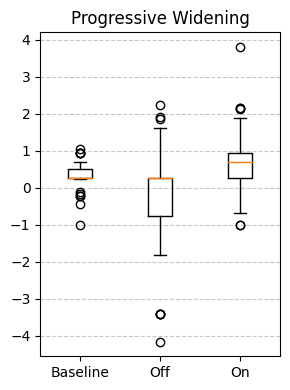

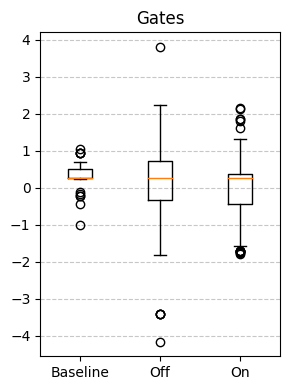

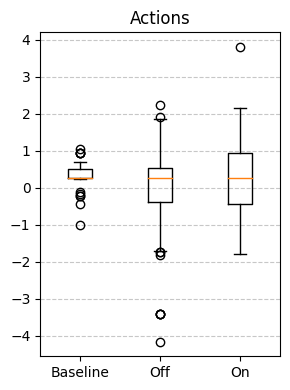

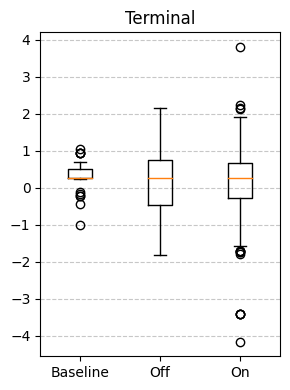

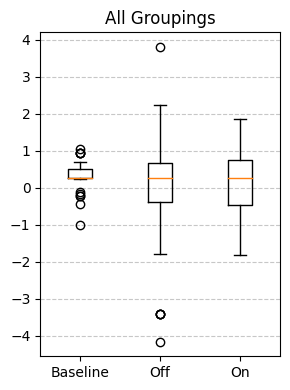

In [14]:
to_sort = ["pw","gates","actions","terminal","change"]
names = ["Progressive Widening", "Gates", "Actions", "Terminal", "All Groupings"]
in_group = []
standard = []
out_group = []
for name, sort_by in zip(names, to_sort):

    in_group = []
    standard = []
    out_group = []
    for variant in qc_variant_results.keys():
        if sort_by is not "change" and "change" in variant:
            out_group = out_group + qc_variant_results[variant]
        elif sort_by in variant:
            in_group = in_group + qc_variant_results[variant]
        elif "standard_nc_prob" == variant:
            standard = standard + qc_variant_results[variant]
        elif "standard" not in variant:
            out_group = out_group + qc_variant_results[variant]
    plt.figure(figsize=(3, 4))
    plt.boxplot([ standard, out_group, in_group], labels=[ 'Baseline', f'Off',f"On"])
    plt.title(f"{name}")
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add horizontal grid lines
    plt.show()
        

                
            

In [15]:
table_df
gates = analysing_utils.load_circuit_gates()


In [16]:
gates['vqls_1']

{'actions': {'h': 3, 'r': 2, 'rx': 1, 'ry': 0, 'rz': 1, 'cx': 0},
 'actions_change_gates_pw_swap': {'h': 4,
  'r': 2,
  'rx': 1,
  'ry': 0,
  'rz': 1,
  'cx': 1},
 'actions_change_gates_pw_swap_terminal': {'h': 4,
  'r': 2,
  'rx': 0,
  'ry': 1,
  'rz': 1,
  'cx': 1},
 'actions_change_gates_swap': {'h': 3,
  'r': 2,
  'rx': 1,
  'ry': 0,
  'rz': 1,
  'cx': 0},
 'actions_change_gates_swap_terminal': {'h': 4,
  'r': 2,
  'rx': 1,
  'ry': 0,
  'rz': 1,
  'cx': 0},
 'actions_gates': {'h': 4, 'r': 3, 'rx': 1, 'ry': 1, 'rz': 1, 'cx': 0},
 'actions_gates_pw': {'h': 4, 'r': 3, 'rx': 1, 'ry': 1, 'rz': 1, 'cx': 0},
 'actions_gates_pw_terminal': {'h': 4,
  'r': 2,
  'rx': 1,
  'ry': 0,
  'rz': 1,
  'cx': 0},
 'actions_gates_terminal': {'h': 4,
  'r': 3,
  'rx': 1,
  'ry': 0,
  'rz': 2,
  'cx': 0},
 'actions_pw': {'h': 3, 'r': 2, 'rx': 1, 'ry': 0, 'rz': 1, 'cx': 0},
 'actions_pw_terminal': {'h': 4, 'r': 3, 'rx': 1, 'ry': 1, 'rz': 1, 'cx': 0},
 'actions_terminal': {'h': 4, 'r': 2, 'rx': 0, 'ry': 1,